In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch import Tensor
import torch.nn.functional as F

from matplotlib import pyplot as plt
import seaborn as sns

from peint.data.datamodule import PLMRDataModule
from peint.data.datasets.ctmc import CTMCDataset
from peint.models.modules.ctmc_module import CTMCModule
from peint.models.nets.ctmc import NeuralCTMC

from evo.dataset import ComplexCherriesDataset
from evo.tokenization import Vocab

from tqdm import tqdm
tqdm.pandas()

In [4]:
# Load trained joint model from checkpoint
ckpt_dir = Path("/accounts/projects/yss/stephen.lu/peint/logs/train/runs/2025-10-20_20-11-13/checkpoints")
ckpt_path = ckpt_dir / "epoch_004.ckpt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

module = CTMCModule.load_from_checkpoint(ckpt_path, map_location=device, strict=False)
module = module.eval()

net: NeuralCTMC = module.net
vocab: Vocab = net.vocab

Using device: cuda


/accounts/projects/yss/stephen.lu/peint/.venv/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.


In [5]:
import tempfile

def dataloader_from_transitions(transitions, batch_size=32, mask_prob=0.0, datapath=None):
    if datapath is None:
        datafile = tempfile.NamedTemporaryFile(delete=False, suffix=".txt")
        with open(datafile.name, "w") as f:
            f.write("{0} transitions\n".format(len(transitions)))
            f.write("\n".join(transitions))
        datapath = datafile.name
    dataset = CTMCDataset(
        dataset=ComplexCherriesDataset(data_file=datapath, min_t=0., chain_id_offset=1),
        sep_token=".",
        vocab=vocab,
    )
    dataloader = PLMRDataModule(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )._dataloader_template(dataset=dataset, training=False)
    return dataloader

def infer_log_likelihoods(dataloader, module, n_batches = 100):
    # run inference on the dataloader
    lls, bls, ppl = [], [], []

    for batch in tqdm(dataloader, desc="Inference"):
        batch = [b.to(device) for b in batch]
        
        x, y, t, x_sizes = batch

        with torch.no_grad() and torch.autocast(device_type="cuda", dtype=torch.bfloat16):
            Q: Tensor = net(x, x_sizes=x_sizes)  # (B, L, V, V)
            log_probs: Tensor = module.forward(x, t, x_sizes=x_sizes, Q=Q)  # (B, L, V)

        # Keep unreduced to get per-site time likelihood (B, L)
        nll = F.cross_entropy(
            log_probs.transpose(-1, -2),
            y,
            ignore_index=vocab.pad_idx,
            reduction="none",
        ).detach()

        # compute perplexity
        padding_mask = y != vocab.pad_idx
        ll = -nll * padding_mask.float()
        ll = ll.sum(dim=-1)
        lls.append(ll.detach().cpu().numpy())
        bls.append(t.detach().cpu().numpy())
        nll_mean = (nll * padding_mask.float()).sum(dim=-1) / padding_mask.float().sum(dim=-1)
        ppl.append(torch.exp(nll_mean).detach().cpu().numpy())

        n_batches -= 1
        if n_batches == 0:
            break

    lls = np.concatenate(lls)
    bls = np.concatenate(bls)
    ppl = np.concatenate(ppl)
    return lls, bls, ppl

def decode_sequence_from_toks(toks):
    tokens = []
    for tok in toks:
        if tok == vocab.bos_idx:
            continue
        if tok == vocab.eos_idx or tok == vocab.pad_idx:
            break
        tokens.append(vocab.token(tok))
    return "".join(tokens)    

In [9]:
# load the test dataset and infer log likelihoods with the CTMC model
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)
lls, bls, ppl = infer_log_likelihoods(dataloader, module, n_batches=-1)

Inference: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1888/1888 [02:22<00:00, 13.25it/s]


In [ ]:
print('test perplexity: ', np.mean(ppl))
print(lls)

# save branch, lls, and ppls to a dataframe
df = pd.DataFrame({
    "branch": bls[:,0],
    "log_likelihood": lls,
    "perplexity": ppl,
})

df.to_csv("ctmc_model_d4.csv", index=False)

test perplexity:  1.2291098
[ -66.22939  -71.31071  -49.16594 ...  -80.30189  -58.96632 -103.55792]


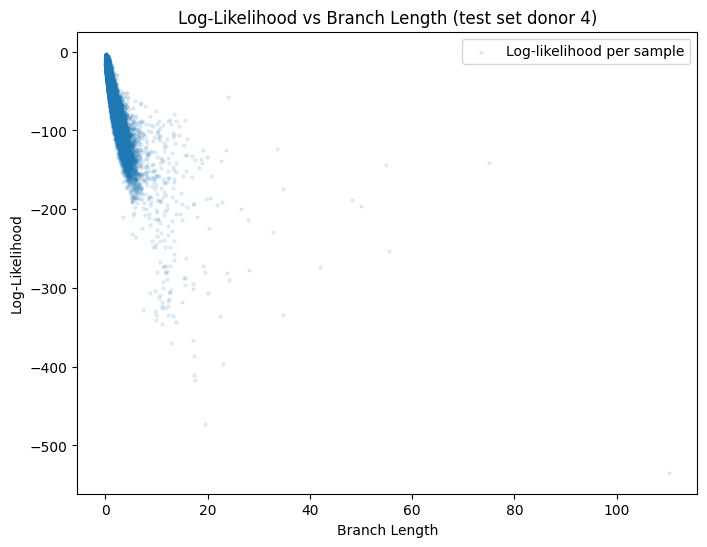

In [11]:
# plot the binned likelihoods according to the branch length
df = pd.DataFrame({'ll': lls, 'branch_length': bls[:, 0], 'ppl': ppl})
df["bl_bin"] = df["branch_length"] // df["branch_length"].quantile(.15).astype(float)
binned_df = df.groupby("bl_bin").mean()

fig, ax = plt.subplots(figsize=(8, 6))
# ax.scatter(binned_df.branch_length, binned_df.ll, label="Binned log-likelihood", s=10)
ax.scatter(df.branch_length, df.ll, alpha=0.1, label="Log-likelihood per sample", s=5)

ax.set_xlabel("Branch Length")
ax.set_ylabel("Log-Likelihood")
ax.set_title("Log-Likelihood vs Branch Length (test set donor 4)")
ax.legend()
plt.show()

## Now let's try sampling some proteins from the ctmc model

In [6]:
# load the test dataset
datapath = Path("/accounts/projects/yss/stephen.lu/peint/data/wyatt/subs/edges_joint/aa/d4.txt")
dataloader = dataloader_from_transitions(transitions=None, datapath=datapath, batch_size=32)

In [92]:
# first we try generating child sequences using the one-shot independent site method
real_parent_hv_seqs, real_parent_lt_seqs = [], []
real_child_hv_seqs, real_child_lt_seqs = [], []
ind_sim_child_hv_seqs, ind_sim_child_lt_seqs = [], []
dep_sim_child_hv_seqs, dep_sim_child_lt_seqs = [], []
branch_lengths = []
n_batches = 50

for batch in tqdm(dataloader, desc="Inference"):
    batch = [b.to(device) for b in batch]
    x, y, t, x_sizes = batch

    # get heavy chain lengths
    hc_lens, lc_lens = x_sizes[:,0], x_sizes[:,1]

    # decode the true parent and child sequence using the vocab
    true_parent_seqs = [decode_sequence_from_toks(x[i].cpu().numpy()) for i in range(x.size(0))]
    true_child_seqs = [decode_sequence_from_toks(y[i].cpu().numpy()) for i in range(y.size(0))]
    true_pr_hv_seqs, true_pr_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_parent_seqs, hc_lens)])
    true_ch_hv_seqs, true_ch_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(true_child_seqs, hc_lens)])
    assert all([len(tp)+2 == ys.sum().item() for tp, ys in zip(true_parent_seqs, x_sizes)])
    assert all([len(tc)+2 == ys.sum().item() for tc, ys in zip(true_child_seqs, x_sizes)])

    # sample a child sequence using the model
    with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
        y_ind_decoded = net.generate_with_independent_sites(t=t, x=x, x_sizes=x_sizes)
        y_dep_decoded = net.generate_with_fake_gillespie(t=t, x=x, x_sizes=x_sizes)

    sim_ind_child_seqs = [decode_sequence_from_toks(y_ind_decoded[i].cpu().numpy()) for i in range(y_ind_decoded.size(0))]
    sim_ind_hv_seqs, sim_ind_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_ind_child_seqs, hc_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_ind_child_seqs)])
    
    sim_dep_child_seqs = [decode_sequence_from_toks(y_dep_decoded[i].cpu().numpy()) for i in range(y_dep_decoded.size(0))]
    sim_dep_hv_seqs, sim_dep_lt_seqs = zip(*[(seq[:hl], seq[hl+1:]) for seq, hl in zip(sim_dep_child_seqs, hc_lens)])
    assert all([len(tc) == len(sc) for tc, sc in zip(true_child_seqs, sim_dep_child_seqs)])

    real_parent_hv_seqs.extend(true_pr_hv_seqs)
    real_parent_lt_seqs.extend(true_pr_lt_seqs)
    real_child_hv_seqs.extend(true_ch_hv_seqs)
    real_child_lt_seqs.extend(true_ch_lt_seqs)
    ind_sim_child_hv_seqs.extend(sim_ind_hv_seqs)
    ind_sim_child_lt_seqs.extend(sim_ind_lt_seqs)
    dep_sim_child_hv_seqs.extend(sim_dep_hv_seqs)
    dep_sim_child_lt_seqs.extend(sim_dep_lt_seqs)
    branch_lengths.extend(t.squeeze().detach().cpu().numpy().tolist())

    n_batches -= 1
    if n_batches == 0:
        break

Inference:   3%|█▋                                                                 | 49/1888 [03:46<2:21:54,  4.63s/it]


In [93]:
# calculate hamming distances between corresponding real and simulated sequences
def compute_hamming_distance(seq1, seq2):
    assert len(seq1) == len(seq2)
    return sum(c1 != c2 for c1, c2 in zip(seq1, seq2))

hv_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_hv_seqs, dep_sim_child_hv_seqs)]
lt_ind_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_aa_hamming_dists = [compute_hamming_distance(r, s) for r, s in zip(real_child_lt_seqs, dep_sim_child_lt_seqs)]
_len = len(hv_ind_aa_hamming_dists)

data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_ind_aa_hamming_dists + hv_dep_aa_hamming_dists + lt_ind_aa_hamming_dists + lt_dep_aa_hamming_dists,
    "chain": ["heavy"] * 2 * _len + ["light"] * 2 * _len,
    "method": ["matrix exponential"] * _len + ["gillespie"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

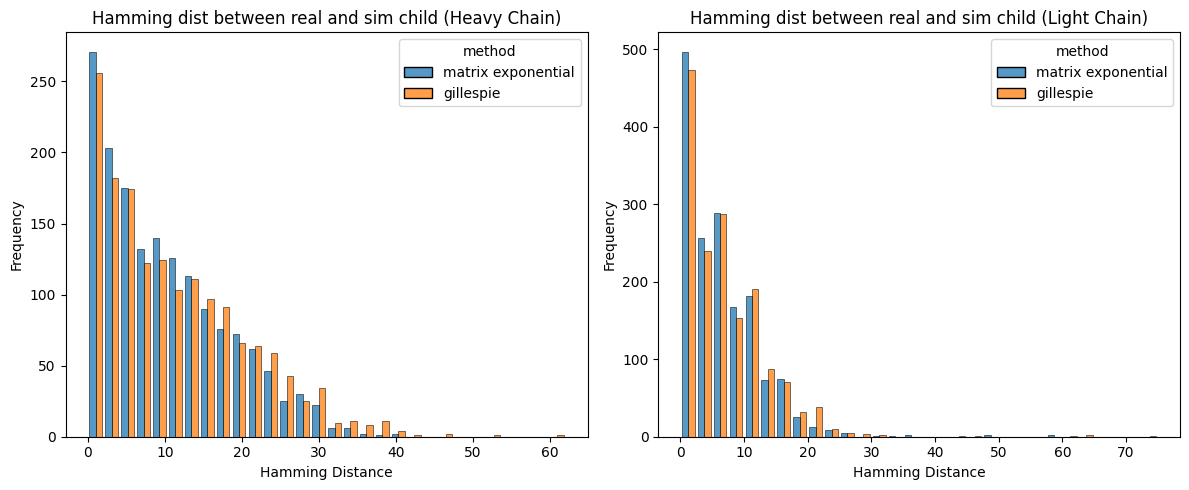

In [94]:
# plot a histogram of the hamming distances for heavy and light chains on the amino acid level (side by side) colored by method
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=data_df[data_df["chain"] == "heavy"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[0], legend=True)
sns.histplot(data=data_df[data_df["chain"] == "light"], x="dist", hue="method", multiple="dodge", shrink=0.8, bins=30, ax=ax[1], legend=True)

# add labels and legend please
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel('Hamming Distance')
ax[0].set_ylabel('Frequency')
ax[1].set_title('Hamming dist between real and sim child (Light Chain)')
ax[1].set_xlabel('Hamming Distance')
ax[1].set_ylabel('Frequency')
# ax[0].legend(title='Method')
# ax[1].legend(title='Method')

plt.tight_layout()
plt.show()

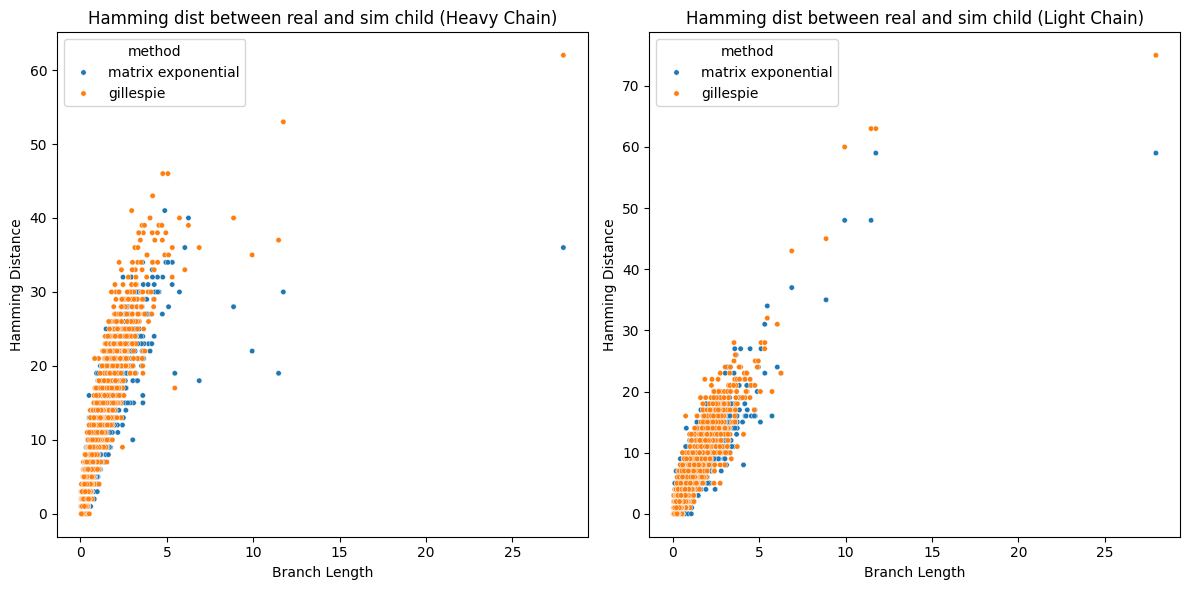

In [95]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=data_df[data_df["chain"] == "heavy"], x="bl", y="dist", hue="method", ax=ax[0], legend=True, s=15)
sns.scatterplot(data=data_df[data_df["chain"] == "light"], x="bl", y="dist", hue="method", ax=ax[1], legend=True, s=15)

# add titles and labels
ax[0].set_title("Hamming dist between real and sim child (Heavy Chain)")
ax[0].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[1].set_title("Hamming dist between real and sim child (Light Chain)")
ax[1].set_xlabel("Branch Length")
ax[1].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [96]:
# calculate hamming distance between real parent and all child sequences, real and fake

hv_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, real_child_hv_seqs)]
hv_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, ind_sim_child_hv_seqs)]
hv_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_hv_seqs, dep_sim_child_hv_seqs)]

lt_real_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, real_child_lt_seqs)]
lt_ind_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, ind_sim_child_lt_seqs)]
lt_dep_hd = [compute_hamming_distance(r, s) for r, s in zip(real_parent_lt_seqs, dep_sim_child_lt_seqs)]

_len = len(hv_real_hd)

hv_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": hv_real_hd + hv_ind_hd + hv_dep_hd, 
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})
lt_data_df = pd.DataFrame({
    "bl": branch_lengths + branch_lengths + branch_lengths,
    "dist": lt_real_hd + lt_ind_hd + lt_dep_hd,
    "method": ["data"] * _len + ["matrix exponential"] * _len + ["gillespie"] * _len,
})

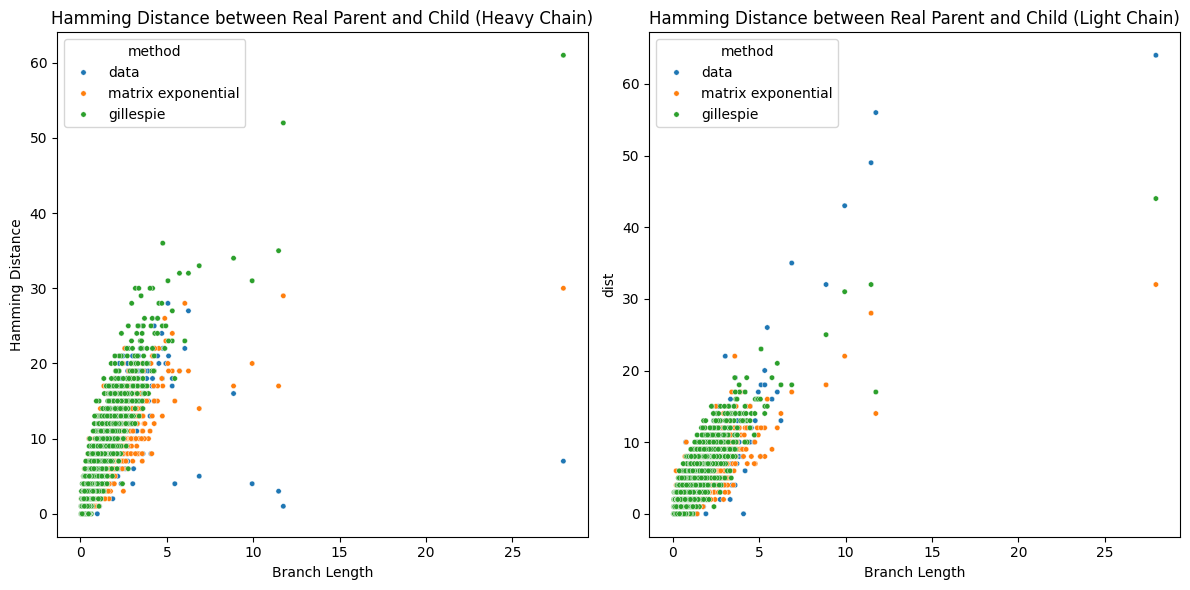

In [97]:
# scatter branch length vs hamming distance between real and sim children, for heavy and light chain side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=hv_data_df, x="bl", y="dist", hue="method", ax=ax[0], legend="full", s=15)
sns.scatterplot(data=lt_data_df, x="bl", y="dist", hue="method", ax=ax[1], legend="full", s=15)

ax[0].set_title("Hamming Distance between Real Parent and Child (Heavy Chain)")
ax[1].set_title("Hamming Distance between Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

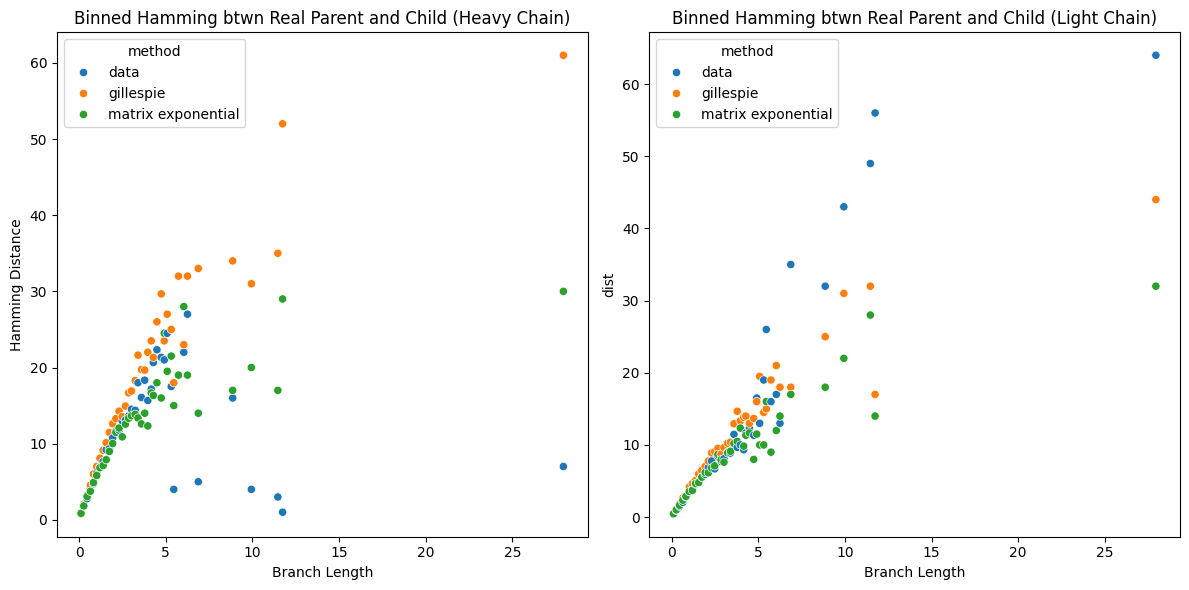

In [99]:
# do this plot again, but now bin by branch length
hv_quantile, lt_quantile = hv_data_df.bl.quantile(0.15), lt_data_df.bl.quantile(0.15)
hv_data_df["bl_bin"] = hv_data_df.bl // hv_quantile.astype(float)
lt_data_df["bl_bin"] = lt_data_df.bl // lt_quantile.astype(float)

binned_hv_u = hv_data_df.groupby(by=["bl_bin", "method"]).mean()
binned_lt_u = lt_data_df.groupby(by=["bl_bin", "method"]).mean()
binned_hv_s = hv_data_df.groupby(by=["bl_bin", "method"]).std()
binned_lt_s = lt_data_df.groupby(by=["bl_bin", "method"]).std()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

sns.scatterplot(data=binned_hv_u, x="bl", y="dist", hue="method", ax=ax[0], legend="full")
sns.scatterplot(data=binned_lt_u, x="bl", y="dist", hue="method", ax=ax[1], legend="full")

# Add confidence intervals
# ax[0].fill_between(
#     binned_hv_u.bl,
#     binned_hv_u.dist - binned_hv_s.dist,
#     binned_hv_u.dist + binned_hv_s.dist,
#     alpha=0.2,
# )
# ax[1].fill_between(
#     binned_lt_u.bl,
#     binned_lt_u.dist - binned_lt_s.dist,
#     binned_lt_u.dist + binned_lt_s.dist,
#     alpha=0.2,
# )

ax[0].set_title("Binned Hamming btwn Real Parent and Child (Heavy Chain)")
ax[1].set_title("Binned Hamming btwn Real Parent and Child (Light Chain)")
ax[0].set_xlabel("Branch Length")
ax[1].set_xlabel("Branch Length")
ax[0].set_ylabel("Hamming Distance")
ax[0].set_ylabel("Hamming Distance")

plt.tight_layout()
plt.show()

In [100]:
# save sampled sequences to disk, use different file for dep and ind methods
# format should be csv with real parent, real child, simulated child, and branch length

# Create DataFrames for independent and dependent methods
ind_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": ind_sim_child_hv_seqs,
    "sim_child_lt": ind_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

dep_data = {
    "real_parent_hv": real_parent_hv_seqs,
    "real_parent_lt": real_parent_lt_seqs,
    "real_child_hv": real_child_hv_seqs,
    "real_child_lt": real_child_lt_seqs,
    "sim_child_hv": dep_sim_child_hv_seqs,
    "sim_child_lt": dep_sim_child_lt_seqs,
    "branch_length": branch_lengths,
}

ind_df = pd.DataFrame(ind_data)
dep_df = pd.DataFrame(dep_data)

# Save to CSV files
ind_df.to_csv("notebooks/gen_eval/ctmc_mat_exp.csv", index=False)
dep_df.to_csv("notebooks/gen_eval/ctmc_gillespie.csv", index=False)